<a href="https://colab.research.google.com/github/rahul-solanki-iitj/mlops-goodreads-genre-classifier/blob/main/Intrusion_Detection_System_KDD_Cup_Dataset_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook comprises of following things:

#####**Data Acquisition:** The KDD Cup 1999 dataset was downloaded using kagglehub.

#####**File Path Resolution:** Initially, a find_file function is implemented to recursively search the downloaded directory, resolving FileNotFoundError.

#####**Column Name Extraction:** Column names for the dataset were dynamically extracted from the kddcup.names file. we need to select after first line where the first line (attack types) can be mistaken for a column names, ensuring proper mapping.

#####**Data Loading and Initial Inspection:** The dataset was loaded into a Pandas DataFrame using the extracted column names. Initial checks confirmed the shape of the data and the absence of missing values.

#####**Feature Engineering and Preprocessing:**
  

1.     An 'Attack Type' column was derived from the 'target' column, mapping specific attack names to broader categories (e.g., 'neptune' to 'dos').
  

2.     Categorical features like protocol_type and flag were mapped to numerical values.


3.     Highly correlated features and features with no variance (e.g., is_host_login, num_outbound_cmds) were identified and dropped to simplify the model and prevent multicollinearity.
  
4.     The service column was dropped as it contained too many unique values for one-hot encoding without significant feature engineering.
5.     The features were scaled using MinMaxScaler to normalize their ranges, which is crucial for many machine learning algorithms.




#####**Data Splitting:** The dataset is split into training (67%) and testing (33%) sets for model development and evaluation.

#####**Model Training and Evaluation:** Several classification models (**Naive Bayes, Decision Tree, Random Forest, SVM, Logistic Regression, Gradient Boosting**) were trained on the preprocessed data. Their training and testing accuracies, along with execution times, were calculated and displayed, showing generally high performance across the models for this dataset.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Download KDD Cup 1999 Dataset from Kaggle

We will use `kagglehub` to download the dataset. Once downloaded, the files `kddcup.names.txt` and `kddcup.data_10_percent_corrected` will be available in the specified path.

In [ ]:
import kagglehub
import os

# Download the dataset
path_to_dataset = kagglehub.dataset_download("galaxyh/kdd-cup-1999-data")

print("Path to dataset files:", path_to_dataset)

# Debugging: list the downloaded content to for correct files
print("\n--- Contents of downloaded dataset directory ---")
for root, dirs, files in os.walk(path_to_dataset):
    level = root.replace(path_to_dataset, '').count(os.sep)
    indent = ' ' * 4 * (level) # 4 spaces per level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')
print("----------------------------------------------\n")

# Function to find a file recursively within the base path
def find_file(base_path, filename):
    for root, dirs, files in os.walk(base_path):
        if filename in files:
            return os.path.join(root, filename)
    return None

# Construct full paths to the required files using the find_file function
kddcup_names_path = find_file(path_to_dataset, 'kddcup.names')
kddcup_data_path = find_file(path_to_dataset, 'kddcup.data_10_percent_corrected')

if not kddcup_names_path:
    raise FileNotFoundError(f"kddcup.names not found in {path_to_dataset} or its subdirectories.")
if not kddcup_data_path:
    raise FileNotFoundError(f"kddcup.data_10_percent_corrected not found in {path_to_dataset} or its subdirectories.")

Path to dataset files: /root/.cache/kagglehub/datasets/galaxyh/kdd-cup-1999-data/versions/1

--- Contents of downloaded dataset directory ---
1/
    kddcup.data_10_percent.gz
    kddcup.names
    kddcup.testdata.unlabeled.gz
    kddcup.data.gz
    kddcup.testdata.unlabeled_10_percent.gz
    typo-correction.txt
    kddcup.data.corrected
    kddcup.newtestdata_10_percent_unlabeled.gz
    kddcup.data_10_percent_corrected
    training_attack_types
    corrected.gz
    kddcup.data/
        kddcup.data
    kddcup.data_10_percent/
        kddcup.data_10_percent
    kddcup.newtestdata_10_percent_unlabeled/
        kddcup.newtestdata_10_percent_unlabeled
    corrected/
        corrected
    kddcup.testdata.unlabeled_10_percent/
        kddcup.testdata.unlabeled_10_percent
    kddcup.testdata.unlabeled/
        kddcup.testdata.unlabeled
----------------------------------------------



In [ ]:
with open(kddcup_names_path, 'r') as f:
    print(f.read())

back,buffer_overflow,ftp_write,guess_passwd,imap,ipsweep,land,loadmodule,multihop,neptune,nmap,normal,perl,phf,pod,portsweep,rootkit,satan,smurf,spy,teardrop,warezclient,warezmaster.
duration: continuous.
protocol_type: symbolic.
service: symbolic.
flag: symbolic.
src_bytes: continuous.
dst_bytes: continuous.
land: symbolic.
wrong_fragment: continuous.
urgent: continuous.
hot: continuous.
num_failed_logins: continuous.
logged_in: symbolic.
num_compromised: continuous.
root_shell: continuous.
su_attempted: continuous.
num_root: continuous.
num_file_creations: continuous.
num_shells: continuous.
num_access_files: continuous.
num_outbound_cmds: continuous.
is_host_login: symbolic.
is_guest_login: symbolic.
count: continuous.
srv_count: continuous.
serror_rate: continuous.
srv_serror_rate: continuous.
rerror_rate: continuous.
srv_rerror_rate: continuous.
same_srv_rate: continuous.
diff_srv_rate: continuous.
srv_diff_host_rate: continuous.
dst_host_count: continuous.
dst_host_srv_count: con

In [ ]:
columns = []
with open(kddcup_names_path, 'r') as f:
    # Skip the first line as it contains attack types, not feature names
    next(f)
    for line in f:
        line = line.strip()
        if line and not line.startswith('|'): # Ignore empty lines and comments
            # Extract the feature name before the colon
            column_name = line.split(':')[0].strip()
            if column_name: # Ensure it's not an empty string after stripping
                columns.append(column_name)

columns.append('target') # The 'target' column is not in kddcup.names, but in the data file
print(f"Number of columns extracted: {len(columns)}")

Number of columns extracted: 42


'training_attack_types.txt' is not directly present in the downloaded dataset, and we need to create dictionary for attack _types.

A connection is a sequence of TCP packets starting and ending at some well defined times, between which data flows to and from a source IP address to a target IP address under some well defined protocol.  Each connection is labeled as either normal, or as an attack, with exactly one specific attack type.  Each connection record consists of about 100 bytes.

Attacks fall into four main categories:
#####**DOS:** denial-of-service, e.g. syn flood.
#####**R2L:** unauthorized access from a remote machine, e.g., guessing password.
#####**U2R:** unauthorized access to administrative level /local superuser /root privileges, e.g., various ``buffer overflow'' attacks.
#####**probing:** surveillance and other probing, e.g., port scanning.


> For more info https://kdd.ics.uci.edu/databases/kddcup99/task.html

In [ ]:
attacks_types = {
    'normal': 'normal',
'back': 'dos',
'buffer_overflow': 'u2r',
'ftp_write': 'r2l',
'guess_passwd': 'r2l',
'imap': 'r2l',
'ipsweep': 'probe',
'land': 'dos',
'loadmodule': 'u2r',
'multihop': 'r2l',
'neptune': 'dos',
'nmap': 'probe',
'perl': 'u2r',
'phf': 'r2l',
'pod': 'dos',
'portsweep': 'probe',
'rootkit': 'u2r',
'satan': 'probe',
'smurf': 'dos',
'spy': 'r2l',
'teardrop': 'dos',
'warezclient': 'r2l',
'warezmaster': 'r2l',
}

In [ ]:
df = pd.read_csv(kddcup_data_path, names = columns)

# Adding Attack Type column
df['Attack Type'] = df.target.apply(lambda r:attacks_types[r[:-1]])
df.sample(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
367759,0,tcp,ssh,S0,0,0,0,0,0,0,...,0.05,0.06,0.0,0.0,1.0,1.0,0.0,0.0,neptune.,dos
132802,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.,dos
435274,0,icmp,ecr_i,SF,520,0,0,0,0,0,...,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.,dos
158439,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.,dos
258181,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.,dos


In [ ]:
df.shape

(494021, 43)

In [ ]:
df.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [ ]:
num_cols = df._get_numeric_data().columns

cate_cols = list(set(df.columns)-set(num_cols))
cate_cols.remove('target')
cate_cols.remove('Attack Type')

cate_cols

['flag', 'protocol_type', 'service']

In [ ]:
def bar_graph(feature):
    df[feature].value_counts().plot(kind="bar")

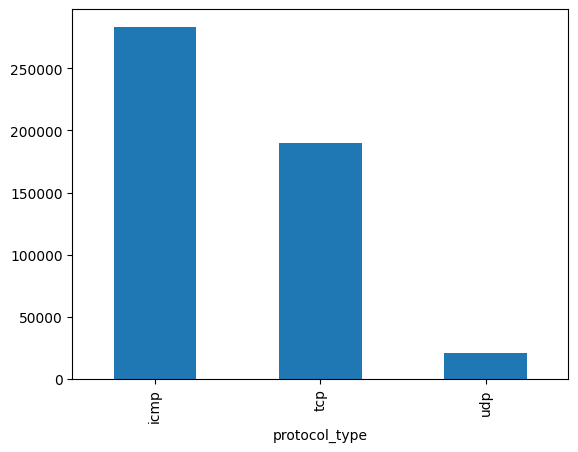

In [ ]:
bar_graph('protocol_type')

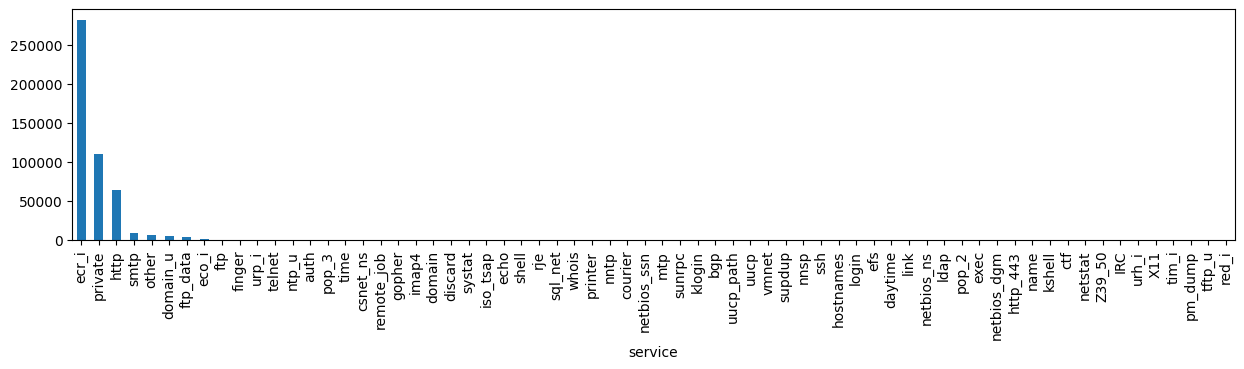

In [ ]:
plt.figure(figsize=(15,3))
bar_graph('service')

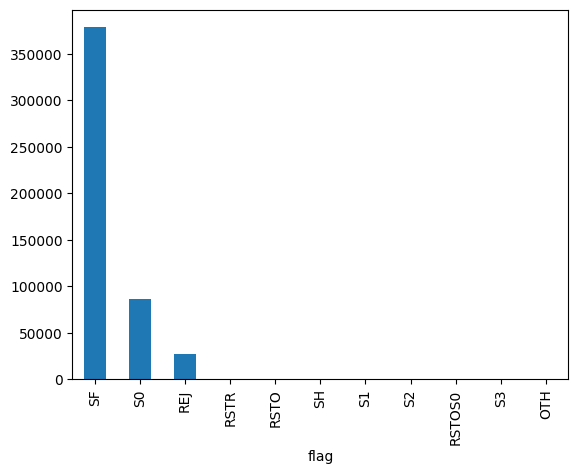

In [ ]:
bar_graph('flag')

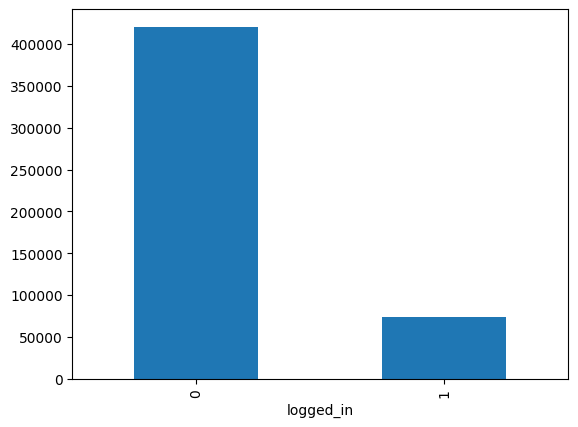

In [ ]:
bar_graph('logged_in')

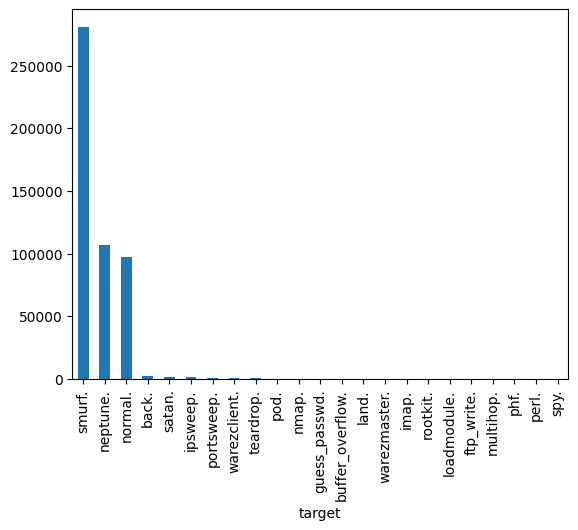

In [ ]:
bar_graph('target')

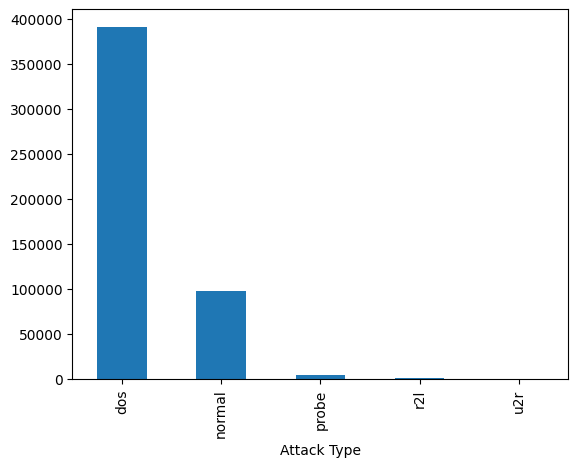

In [ ]:
bar_graph('Attack Type')

In [ ]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'target', 'Attack Type'],
      dtype='object')

In [ ]:
df = df.drop(['target'], axis=1)

In [ ]:
df = df.dropna(axis='columns')

In [ ]:
ndf = df[[col for col in df.columns if df[col].nunique() > 1 and pd.api.types.is_numeric_dtype(df[col])]]

In [ ]:
y = df[['Attack Type']]
X = df.drop(['Attack Type'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(f"Shape of X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}, y_test: {y_test.shape}")

Shape of X_train: (330994, 41), X_test: (163027, 41)
Shape of y_train: (330994, 1), y_test: (163027, 1)


In [ ]:
pmap = {'icmp': 0, 'tcp': 1, 'udp': 2}
X_train['protocol_type'] = X_train['protocol_type'].map(pmap)
X_test['protocol_type'] = X_test['protocol_type'].map(pmap)

In [ ]:
fmap = {'SF': 0, 'S0': 1, 'REJ': 2, 'RSTR': 3, 'RSTO': 4, 'SH': 5, 'S1': 6, 'S2': 7, 'RSTOS0': 8, 'S3': 9, 'OTH': 10}
X_train['flag'] = X_train['flag'].map(fmap)
X_test['flag'] = X_test['flag'].map(fmap)

In [ ]:
X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])

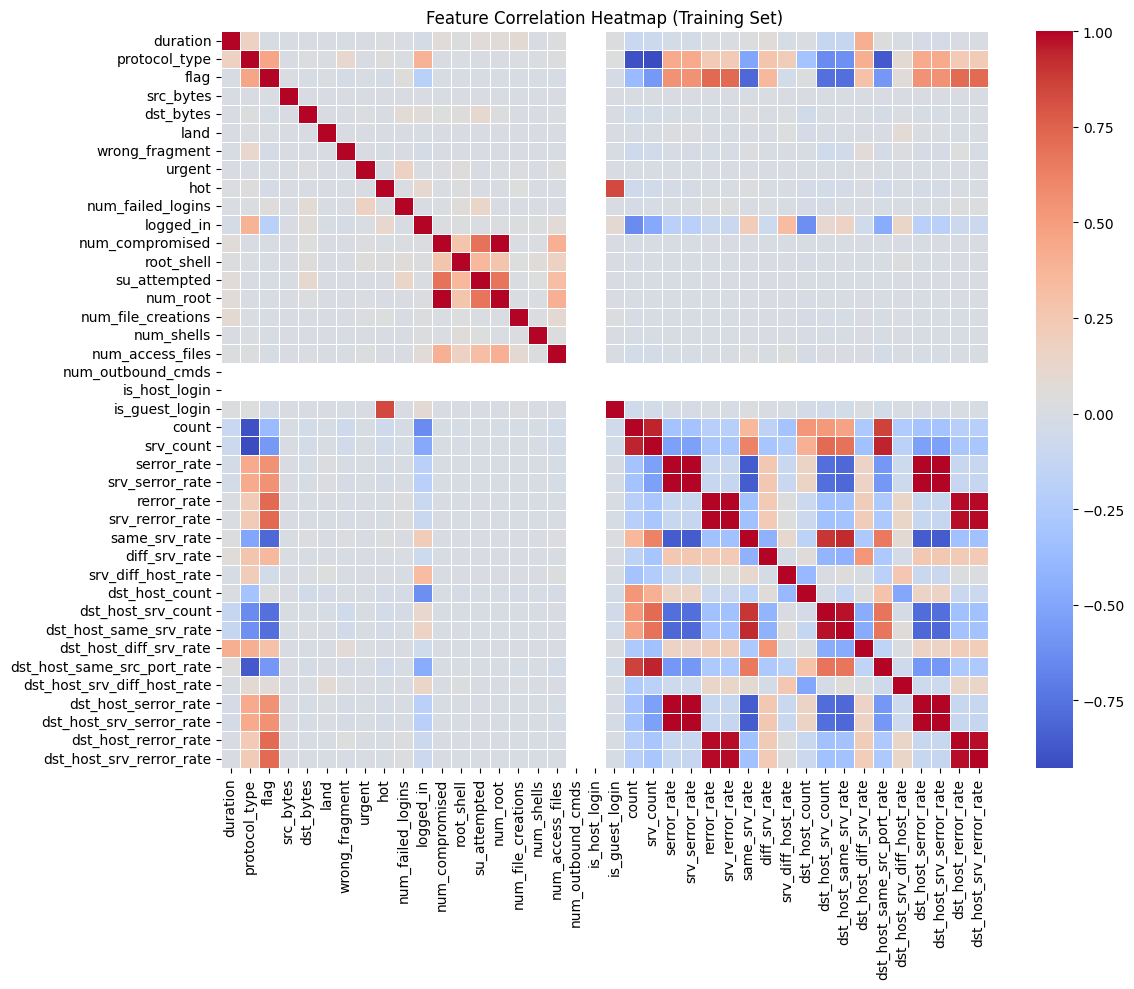

In [ ]:
corr = X_train_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Training Set)')
plt.tight_layout()
plt.show()

In [ ]:
highly_correlated = ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_srv_serror_rate',
                     'dst_host_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
                     'dst_host_same_srv_rate']

In [ ]:
# Highly correlated features offer the exact same information to the model.
# Dropping one of them saves computational memory and speeds up training without losing useful data.
#  For models like Linear Regression or Logistic Regression,
# It becomes difficult for the algorithm to determine which feature is actually
# driving the prediction, which distorts the feature weights and statistical significance.
X_train.drop(columns=highly_correlated, axis=1, inplace=True)
X_test.drop(columns=highly_correlated, axis=1, inplace=True)

In [ ]:
print(X_train[['is_host_login', 'num_outbound_cmds']].nunique())

is_host_login        1
num_outbound_cmds    1
dtype: int64


In [ ]:
# these columns containes only a single unique value across the entire dataset
# columns provide zero predictive value.
X_train.drop(['is_host_login', 'num_outbound_cmds'], axis=1, inplace=True)
X_test.drop(['is_host_login', 'num_outbound_cmds'], axis=1, inplace=True)

In [ ]:
print(f"Shape of X_train after dropping correlated columns: {X_train.shape}")
print(f"Shape of X_test after dropping correlated columns: {X_test.shape}")

Shape of X_train after dropping correlated columns: (330994, 31)
Shape of X_test after dropping correlated columns: (163027, 31)


In [ ]:
X_train.drop('service', axis=1, inplace=True)
X_test.drop('service', axis=1, inplace=True)

In [ ]:
X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])

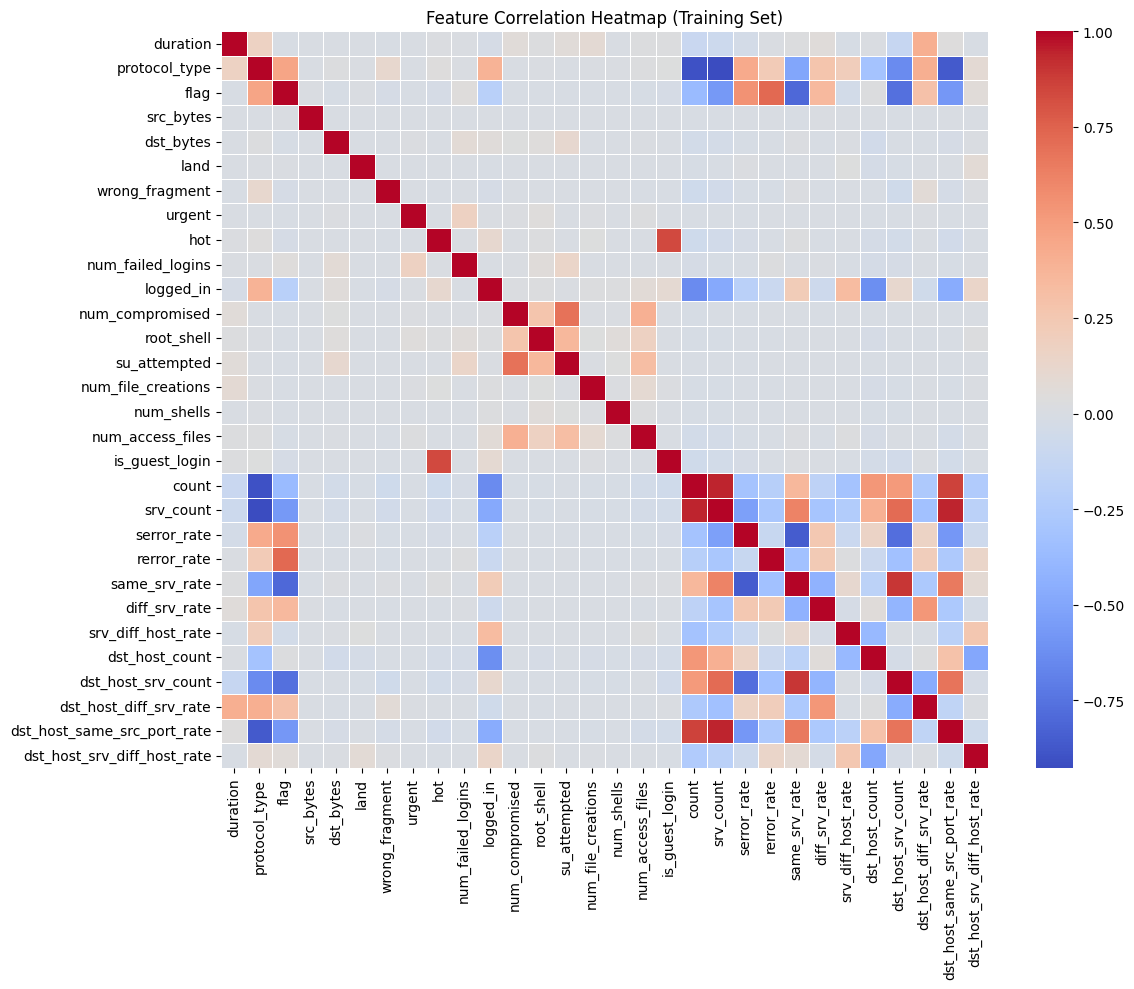

In [ ]:
corr = X_train_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Training Set)')
plt.tight_layout()
plt.show()

In [ ]:
X_train.head(5)

,duration,protocol_type,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,...,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate
482186,1470,2,0,147,105,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,255,1,0.82,1.00,0.00
302290,0,0,0,1032,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,255,255,0.00,1.00,0.00
9330,0,0,0,1032,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,255,255,0.00,1.00,0.00
91417,6,1,0,2872,335,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,188,186,0.02,0.01,0.01
293169,0,0,0,1032,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,255,255,0.00,1.00,0.00


In [ ]:
sc = MinMaxScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print(f"Shape of X_train after scaling: {X_train.shape}")
print(f"Shape of X_test after scaling: {X_test.shape}")

Shape of X_train after scaling: (330994, 30)
Shape of X_test after scaling: (163027, 30)


### Modelling

In [ ]:
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", max_depth=4),
    "Random Forest": RandomForestClassifier(n_estimators=30),
    "SVM": SVC(gamma='scale'),
    "Logistic Regression": LogisticRegression(max_iter=1200000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0),
}

In [ ]:
train_scores = []
test_scores = []
train_times = []
test_times = []

In [ ]:
for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()
    model.fit(X_train, y_train.values.ravel())
    end = time.time()
    train_time = end - start

    start = time.time()
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    end = time.time()
    test_time = end - start

    train_score = accuracy_score(y_train, y_pred_train) * 100
    test_score = accuracy_score(y_test, y_pred_test) * 100

    train_scores.append(train_score)
    test_scores.append(test_score)
    train_times.append(train_time)
    test_times.append(test_time)

    print(f"{name} - Train Accuracy: {train_score:.2f}%, Test Accuracy: {test_score:.2f}%")
    print(f"Training Time: {train_time:.4f}s, Testing Time: {test_time:.4f}s")


Training Naive Bayes...
Naive Bayes - Train Accuracy: 87.95%, Test Accuracy: 87.90%
Training Time: 0.4925s, Testing Time: 0.5021s

Training Decision Tree...
Decision Tree - Train Accuracy: 99.39%, Test Accuracy: 99.38%
Training Time: 1.0032s, Testing Time: 0.0631s

Training Random Forest...
Random Forest - Train Accuracy: 100.00%, Test Accuracy: 99.97%
Training Time: 5.2934s, Testing Time: 0.6529s

Training SVM...
SVM - Train Accuracy: 99.88%, Test Accuracy: 99.88%
Training Time: 117.2052s, Testing Time: 152.0973s

Training Logistic Regression...
Logistic Regression - Train Accuracy: 99.36%, Test Accuracy: 99.36%
Training Time: 8.7182s, Testing Time: 0.0808s

Training Gradient Boosting...
Gradient Boosting - Train Accuracy: 99.91%, Test Accuracy: 99.91%
Training Time: 169.2220s, Testing Time: 2.6748s
